# 3. M-scaling control — is `R` really independent of run depth?

Notebooks 01 and 02 measured `R` and explained `ρ`. Both quote a single number per model, and the
budget strategy behind the whole project — *many ranks, modest depth, and the measured `R` transfers
to any production scale* — rests on `R` being **scale-free**:

$$\mathrm{Var}(\hat G_N)=\Sigma/N,\qquad \mathrm{Var}(P\hat G_N)=P\Sigma P^{\!\top}/N
\;\Longrightarrow\; R \text{ has no } N.$$

That cancellation assumes each rank's sample is in the **CLT regime** — past thermalization and well
beyond the autocorrelation time. Below that threshold `Var(G_i)` is not `Σ/m`, the raw and
symmetrized arms need not approach their asymptotes at the same rate, and `R` can drift with depth.
This notebook measures the drift instead of assuming it away.

**Depth means measurements PER RANK.** A rank is one sample, so its own depth is what decides whether
that sample is asymptotic. DCA's `measurements` input key is the **total over ranks** (every solver
routes it through `parallel::util::getWorkload`), so the driver now records both numbers and
`run_symm_variance.sh` takes the per-rank figure. Runs made before 2026-07-27 stored the total under
the per-rank key — the committed 16-rank "4000" runs are **250 measurements per rank**.

**Design.** At fixed point group, model, and rank count (64), sweep `m ∈ {4,16,64,256,1024,4096}`
per rank at three base seeds. Two things are tracked:

- `R` itself, with a bootstrap-over-ranks CI, and a **paired** CI on the step-to-step difference.
  Pairing is legitimate here: a rank's walker streams are seeded by `hash(global_id + base_seed)` and
  do not depend on `measurements`, so at fixed seed the depth-`m` chain is a **prefix** of the
  depth-`4m` chain on the same rank. `nesting_corr` below verifies that empirically against its
  predicted value `sqrt(m/m')`.
- `m·ΣVar`, which is flat in `m` **iff** the per-rank sample obeys the `1/m` law. This is the
  stricter test: `R` is a ratio, so a departure from `1/m` common to both arms cancels in it, while
  `m·ΣVar` catches the common part too.

In [1]:
import sys, json
sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
S = json.load(open('../runs/m_scaling_summary.json'))
runs = S['runs']
MODELS = sorted({r['model'] for r in runs})
SEEDS = sorted({r['seed'] for r in runs})
print(f"{len(runs)} runs | models {MODELS} | seeds {SEEDS} | "
      f"depths {sorted({r['m'] for r in runs})} | ranks {sorted({r['n_ranks'] for r in runs})}")
print(f"unusable (a rank's accumulated sign hit zero): {sum(1 for r in runs if not r['usable'])}")

38 runs | models ['fe_as', 'square_D4'] | seeds [777, 12345, 20260727] | depths [4, 16, 64, 256, 1024, 4096, 16384] | ranks [64]
unusable (a rank's accumulated sign hit zero): 8


## The headline number

**This is the canonical source for `R`.** Notebooks 01 and 02 read the two committed 16-rank runs and
print single draws — fine for square (±1.6%), badly imprecise for FeAs (95% CI `[2.13, 3.51]`). The
values below average every run above each model's depth floor and quote the standard error across
base seeds, which for FeAs is the dominant uncertainty.

**`R` is on the full support**, summed over every entry. That is the reduction a user actually
experiences: run unsymmetrized and you carry all of them, including the symmetry-forbidden entries,
and their noise propagates downstream. One number, no qualifier. The two right-hand columns are
internal diagnostics — non-null drops the forced-zero entries (related exactly by
`R = R_non-null/(1 − w_null)`, so it adds only `w_null`), and efficiency needs `R_ideal` and is
definable only on the non-null support. Useful for deciding what to do about a model; not for
reporting.

In [2]:
FLOOR = {'square_D4': 64, 'fe_as': 1024}   # per-rank depth floor, established below
print(f"{'model':<10} {'floor':>6} {'runs':>5} {'seeds':>6} {'R (HEADLINE)':>16} "
      f"{'non-null [int]':>16} {'effic. [int]':>14}")
for model in MODELS:
    g = [r for r in runs if r['usable'] and r['model'] == model and r['m'] >= FLOOR[model]]
    by_seed = {}
    for r in g:
        by_seed.setdefault(r['seed'], []).append(r)
    def agg(key):
        per = np.array([np.mean([r[key] for r in v]) for v in by_seed.values()])
        return per.mean(), per.std(ddof=1) / np.sqrt(len(per))
    (rf, ef), (rn, en), (ff, fe_) = agg('R_full'), agg('R_nonnull'), agg('efficiency')
    print(f"{model:<10} {FLOOR[model]:>6} {len(g):>5} {len(by_seed):>6} "
          f"{rf:>9.3f} ± {ef:<5.3f} {rn:>9.3f} ± {en:<5.3f} {ff:>8.1%} ± {fe_:<5.1%}")

model       floor  runs  seeds     R (HEADLINE)   non-null [int]   effic. [int]
fe_as        1024     8      3     3.169 ± 0.139     2.687 ± 0.110    87.5% ± 3.1% 
square_D4      64    12      3     1.041 ± 0.003     1.041 ± 0.003    34.1% ± 0.1% 


## `R` vs depth

Each panel is one model; each line one base seed; the band is the 95% bootstrap-over-ranks CI. The
grey band marks the mean of the deepest two rungs — the working asymptote.

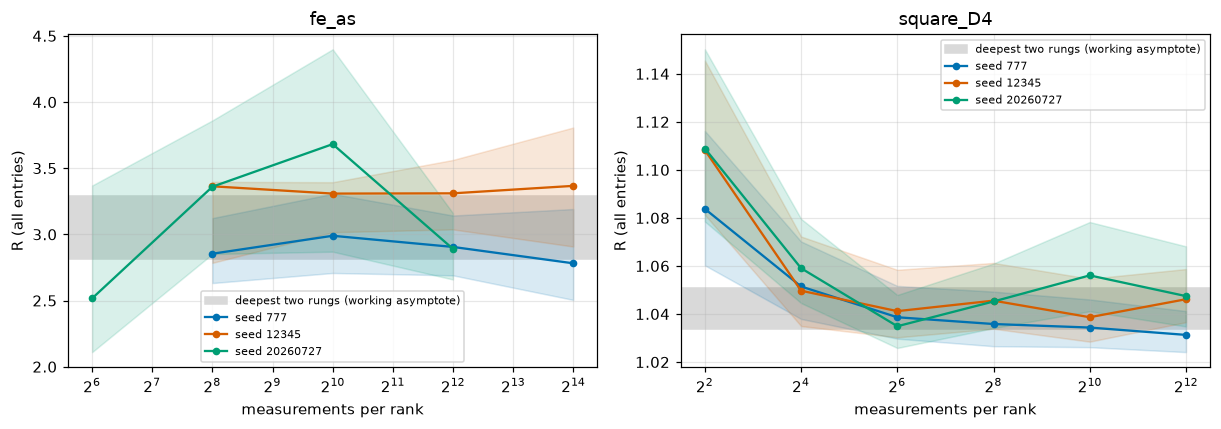

In [3]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5.6*len(MODELS), 4.0))
axes = np.atleast_1d(axes)
for ax, model in zip(axes, MODELS):
    ok = [r for r in runs if r['model'] == model and r['usable']]
    deep = sorted({r['m'] for r in ok})[-2:]
    asym = [r['R_full'] for r in ok if r['m'] in deep]
    ax.axhspan(np.mean(asym)-np.std(asym), np.mean(asym)+np.std(asym), color='0.85',
               label='deepest two rungs (working asymptote)')
    for seed, c in zip(SEEDS, ['#0072B2', '#D55E00', '#009E73']):
        g = sorted([r for r in ok if r['seed'] == seed], key=lambda r: r['m'])
        if not g:
            continue
        x = [r['m'] for r in g]
        y = [r['R_full'] for r in g]
        lo = [r['R_full_ci'][0] for r in g]
        hi = [r['R_full_ci'][1] for r in g]
        ax.fill_between(x, lo, hi, color=c, alpha=.15)
        ax.plot(x, y, 'o-', color=c, label=f'seed {seed}', ms=4)
    ax.set_xscale('log', base=2)
    ax.set(xlabel='measurements per rank', ylabel='R (all entries)', title=model)
    ax.grid(alpha=.3); ax.legend(fontsize=7)
plt.tight_layout()

## The `1/m` law, and where each model's estimator becomes trustworthy

`m·ΣVar` should be flat once the per-rank sample is diffusive. Rising means variance is falling
*slower* than `1/m` — the signature of a sample that has not yet decorrelated.

The second panel is the **sign diagnostic**, and it is a different failure mode entirely.
`G_i = ⟨sign·M⟩_i/⟨sign⟩_i` is a ratio with a **stochastic denominator**. Under a sign problem the
per-rank average sign is `O(⟨s⟩)` with `O(1/√m)` fluctuations, so at shallow depth some rank lands
near zero, its `G_i` blows up, and that one rank dominates `ΣVar`. The estimator becomes
**heavy-tailed long before it becomes wrong**, and at the extreme a rank's sign is exactly zero and
`G_i` is `0/0`. `outlier_index` — largest per-rank `|G|` over the median — is ~1 for a healthy
sample.

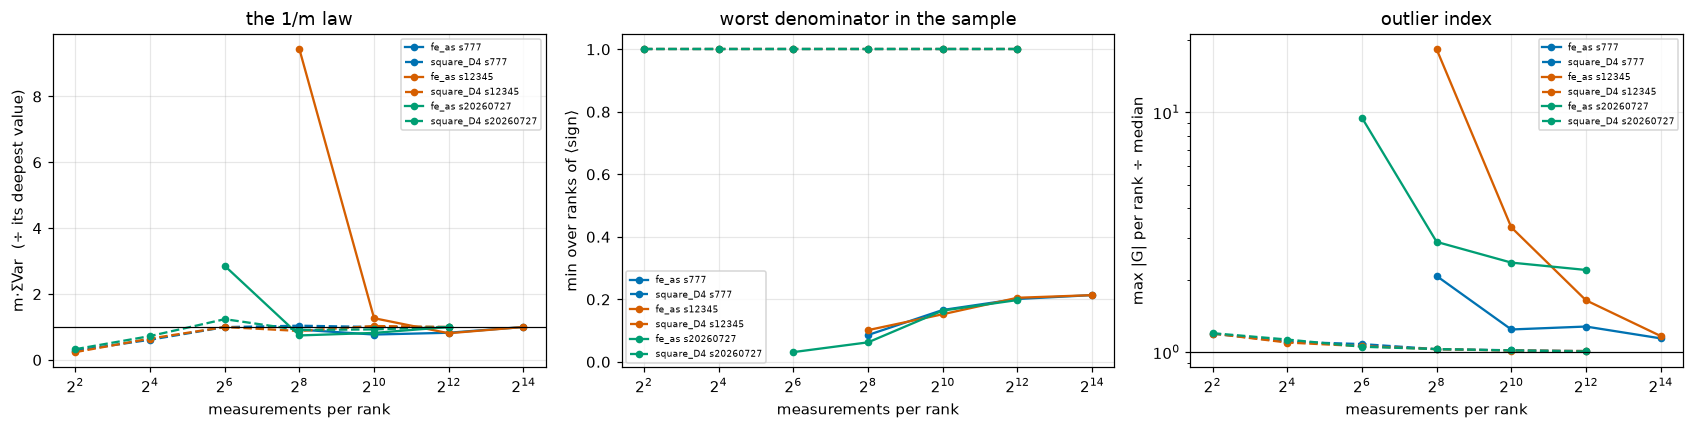

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.0))
for seed, c in zip(SEEDS, ['#0072B2', '#D55E00', '#009E73']):
    for model, ls in zip(MODELS, ['-', '--']):
        g = sorted([r for r in runs if r['usable'] and r['model'] == model and r['seed'] == seed],
                   key=lambda r: r['m'])
        if not g:
            continue
        x = [r['m'] for r in g]
        lab = f'{model} s{seed}'
        # normalized so both models fit one axis: each curve against its own deepest value
        mv = np.array([r['m_times_sum_var'] for r in g])
        axes[0].plot(x, mv/mv[-1], 'o'+ls, color=c, ms=4, label=lab)
        axes[1].plot(x, [r['sign']['min_mean_sign'] for r in g], 'o'+ls, color=c, ms=4, label=lab)
        axes[2].plot(x, [r['sign']['outlier_index'] for r in g], 'o'+ls, color=c, ms=4, label=lab)
axes[0].axhline(1, color='k', lw=.8)
axes[0].set(ylabel='m·ΣVar  (÷ its deepest value)', title='the 1/m law')
axes[1].set(ylabel='min over ranks of ⟨sign⟩', title='worst denominator in the sample')
axes[2].axhline(1, color='k', lw=.8)
axes[2].set(ylabel='max |G| per rank ÷ median', title='outlier index', yscale='log')
for ax in axes:
    ax.set_xscale('log', base=2); ax.set_xlabel('measurements per rank')
    ax.grid(alpha=.3); ax.legend(fontsize=6)
plt.tight_layout()

## What moved underneath `R`

`R` drifting is the symptom; `ρ` is the cause. The expected signature of a sub-asymptotic sample is a
**low** mate-`ρ` at small `m`: a single CT-AUX configuration is not symmetric, so a rank that has
averaged only a handful of them still carries raw configuration-level asymmetry. That is pure
symmetry-**breaking** noise, which `P` removes in full — so `R` is biased **upward**. As `m` grows
that component self-averages away *within* each rank, leaving the symmetric scalar channels `P`
cannot touch, and `ρ` rises to its asymptote while `R` falls to its own.

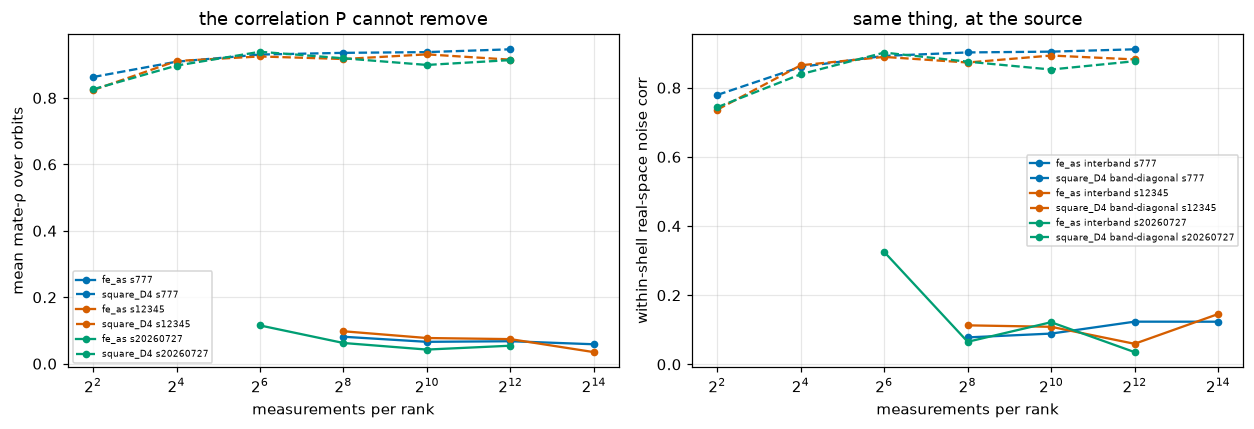

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
for seed, c in zip(SEEDS, ['#0072B2', '#D55E00', '#009E73']):
    for model, ls in zip(MODELS, ['-', '--']):
        g = sorted([r for r in runs if r['usable'] and r['model'] == model and r['seed'] == seed],
                   key=lambda r: r['m'])
        if not g:
            continue
        x = [r['m'] for r in g]
        # variance-weighted-ish summary: mean mate-rho over all non-singleton orbits
        rho = [np.mean([o['rho'] for o in r['orbits'] if o['rho'] is not None]) for r in g]
        blk = sorted(g[0]['mechanism'])[0]
        wi = [r['mechanism'][blk]['within_shell'] for r in g]
        axes[0].plot(x, rho, 'o'+ls, color=c, ms=4, label=f'{model} s{seed}')
        axes[1].plot(x, wi, 'o'+ls, color=c, ms=4, label=f'{model} {blk} s{seed}')
axes[0].set(ylabel='mean mate-ρ over orbits', title='the correlation P cannot remove')
axes[1].set(ylabel='within-shell real-space noise corr', title='same thing, at the source')
for ax in axes:
    ax.set_xscale('log', base=2); ax.set_xlabel('measurements per rank')
    ax.grid(alpha=.3); ax.legend(fontsize=6)
plt.tight_layout()

## Paired step-to-step drift

The marginal CIs above overlap generously, which is a weak test. The paired bootstrap is the sharp
one: resampling the **same rank indices** in both runs cancels the shared randomness of the nested
chains, so it resolves a drift far smaller than either interval suggests. `nesting` reports the
measured per-rank residual correlation against its predicted `sqrt(m/m')` — the licence for pairing
at all.

In [6]:
hdr = f"{'model':<10} {'seed':>9} {'step':>16} {'ΔR (paired 95% CI)':>30} {'nesting meas/pred':>18}"
print(hdr); print('-'*len(hdr))
for d in S['drift']:
    f = d['full']
    flag = 'flat' if f['consistent_with_zero'] else 'DRIFT'
    print(f"{d['model']:<10} {d['seed']:>9} {d['m_from']:>7}->{d['m_to']:<8} "
          f"{f['dR']:>+8.4f} [{f['lo']:+.4f},{f['hi']:+.4f}] {flag:<6} "
          f"{d['nesting_corr']:>8.3f} / {d['nesting_expected']:.3f}")

model           seed             step             ΔR (paired 95% CI)  nesting meas/pred
---------------------------------------------------------------------------------------
fe_as          12345     256->1024      -0.0551 [-0.1200,+0.4621] flat      0.522 / 0.500
fe_as          12345    1024->4096      +0.0019 [-0.2095,+0.3801] flat      0.496 / 0.500
fe_as          12345    4096->16384     +0.0564 [-0.4483,+0.5531] flat      0.515 / 0.500
fe_as       20260727      64->256       +0.8437 [-0.0477,+1.4547] flat      0.383 / 0.500
fe_as       20260727     256->1024      +0.3219 [-0.8076,+1.3508] flat      0.464 / 0.500
fe_as       20260727    1024->4096      -0.7913 [-1.4194,+0.0218] flat      0.463 / 0.500
fe_as            777     256->1024      +0.1356 [-0.2264,+0.4985] flat      0.497 / 0.500
fe_as            777    1024->4096      -0.0843 [-0.4378,+0.2646] flat      0.433 / 0.500
fe_as            777    4096->16384     -0.1237 [-0.4933,+0.3287] flat      0.456 / 0.500
square_D4     

## Conclusion

**`R` is scale-free above a model-dependent depth threshold, and the two models set that threshold by
different mechanisms.**

- **square/D4, β=1 — autocorrelation-limited.** `R` is biased **high** at shallow depth (≈1.11 at
  `m=4` against ≈1.04 asymptotically) and every `4→16` step drifts significantly. From `m ≳ 64` all
  paired steps are flat across all three seeds. The mechanism diagnostics move in lockstep: mate-`ρ`
  on the `m=2` orbits climbs from ≈0.65 to ≈0.85 and within-shell real-space correlation from ≈0.74
  to ≈0.90, then plateau.
- **FeAs, β=5 — sign-limited.** Autocorrelation is not the binding constraint; the ratio estimator
  is. `⟨sign⟩ ≈ 0.25`, so at `m ≤ 64` several of the 64 ranks accumulate a sign of **exactly zero**
  and their `G_i` is `0/0`. Even at `m=256`, where every rank is finite, one rank can carry an 18×
  outlier and single-handedly set `ΣVar`. The depth FeAs needs is whatever keeps the *worst*
  denominator away from zero, which is a stricter requirement than decorrelation.

**Consequence for the design principle.** "Many ranks, modest depth" survives, but *modest* has a
floor, and for a model with a sign problem that floor is set by the sign, not the autocorrelation
time. Adding ranks at fixed shallow depth does **not** fix it — it adds more chances to draw a rank
with a near-zero denominator.

**Consequence for the β ladder (task 3).** The per-rank depth must be re-established at every β, and
the sign diagnostic is the thing to watch: `⟨sign⟩` falls with β, so the depth floor rises with β
independently of the autocorrelation time. The same measurement that certifies the depth also gives
the sign data that task 3 needs to separate the two competing effects on `ρ`.